# CNN Classification — UAV RF Fingerprinting

Trains a 1-D CNN on three feature representations (WPD, STFT, PSD) using
stratified 5-fold cross-validation.  
**Outputs:**
- Per-fold and best-fold model checkpoints  
- Metrics CSV matching Table 1 of the paper  
- Training-curve figures (accuracy + loss per epoch, all folds overlaid)

In [1]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

from rfml_uav.nn.models import get_model

load_dotenv()
DATA_PATH = os.getenv("DATA_PATH")
data_path = os.path.join(DATA_PATH, "balanced")
checkpoints_path = os.path.join(DATA_PATH, "checkpoints/v2")
results_path = os.path.join(DATA_PATH, "results/v2")
figures_path = os.path.join(results_path, "figures")

for p in [checkpoints_path, results_path, figures_path]:
    os.makedirs(p, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
np.random.seed(1)
torch.manual_seed(1)

EPOCHS = 50
BATCH_SIZE = 256
LEARNING_RATE = 0.01
K_FOLDS = 5

CLASS_NAMES = ["Background", "Bebop", "AR", "Phantom"]
N_CLASSES = len(CLASS_NAMES)

# Maps short feature key (used in filenames/CSV) to .npz filename
FEATURE_FILES = {
    "wpd": "Wavelets",
    "stft": "STFT",
    "psd": "PSD",
}

kf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

## Training

In [3]:
def train_cnn(feature_key: str):
    """Train CNN on a single feature set with K-fold cross-validation.

    Returns
    -------
    all_true : ndarray, shape (N,)  — ground-truth labels from all test folds
    all_pred : ndarray, shape (N,)  — predicted labels from all test folds
    history  : dict with keys 'train_loss' and 'train_acc',
               each a list of K lists (one per fold) of length EPOCHS
    """
    filename = FEATURE_FILES[feature_key]

    print(f"\n{'='*60}")
    print(f"  CNN  |  feature={feature_key.upper()}  |  file={filename}.npz")
    print(f"{'='*60}")

    # ── Load data ──────────────────────────────────────────────────────────
    raw = np.load(os.path.join(data_path, f"{filename}.npz"))
    X = raw["X"]                                     # (N, F)
    y = raw["y"].astype(np.int64)                    # (N,)  integer class indices

    print(f"  X: {X.shape}   y: {y.shape}   classes: {np.unique(y).tolist()}")

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    # Pre-load to GPU if dataset fits in VRAM (skip for PSD ~3.4 GB)
    gpu_preloaded = False
    if X_tensor.nbytes < 2 * 1024 ** 3 and device.type == "cuda":
        X_tensor = X_tensor.to(device)
        y_tensor = y_tensor.to(device)
        gpu_preloaded = True
        print(f"  Dataset pre-loaded to GPU ({X_tensor.nbytes / 1024**2:.0f} MB)")

    dataset = TensorDataset(X_tensor, y_tensor)

    # num_workers only makes sense when data lives on CPU
    loader_kwargs = dict(batch_size=BATCH_SIZE, pin_memory=(not gpu_preloaded))
    if not gpu_preloaded:
        loader_kwargs["num_workers"] = 4
        loader_kwargs["persistent_workers"] = True

    all_true = []
    all_pred = []
    history = {"train_loss": [], "train_acc": []}

    best_val_acc = -1.0
    best_fold_idx = 1
    best_state = None

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        fold_num = fold + 1
        print(f"\n--- Fold {fold_num}/{K_FOLDS}  "
              f"(train={len(train_idx)}, val={len(test_idx)}) ---")

        train_loader = DataLoader(
            torch.utils.data.Subset(dataset, train_idx),
            shuffle=True, **loader_kwargs,
        )
        test_loader = DataLoader(
            torch.utils.data.Subset(dataset, test_idx),
            shuffle=False, **loader_kwargs,
        )

        model = get_model("CNN", input_dim=X.shape[1], n_classes=N_CLASSES).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

        fold_loss_hist = []
        fold_acc_hist = []

        # ── Training loop ─────────────────────────────────────────────────
        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for batch_X, batch_y in train_loader:
                if not gpu_preloaded:
                    batch_X = batch_X.to(device, non_blocking=True)
                    batch_y = batch_y.to(device, non_blocking=True)
                batch_X = batch_X.unsqueeze(1)   # (B, 1, F)

                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)

            epoch_loss = running_loss / total
            epoch_acc = 100.0 * correct / total
            fold_loss_hist.append(epoch_loss)
            fold_acc_hist.append(epoch_acc)

            if (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}/{EPOCHS}  "
                      f"loss={epoch_loss:.4f}  acc={epoch_acc:.2f}%")

        history["train_loss"].append(fold_loss_hist)
        history["train_acc"].append(fold_acc_hist)

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        fold_true = []
        fold_pred = []

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                if not gpu_preloaded:
                    batch_X = batch_X.to(device, non_blocking=True)
                batch_X = batch_X.unsqueeze(1)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                fold_true.extend(batch_y.cpu().numpy())
                fold_pred.extend(predicted.cpu().numpy())

        val_acc = 100.0 * np.mean(
            np.array(fold_true) == np.array(fold_pred)
        )
        print(f"  Validation accuracy — fold {fold_num}: {val_acc:.2f}%")

        all_true.extend(fold_true)
        all_pred.extend(fold_pred)

        # ── Save per-fold checkpoint ───────────────────────────────────────
        ckpt = os.path.join(
            checkpoints_path, f"checkpoint_{feature_key}_fold{fold_num}.pt"
        )
        torch.save(model.state_dict(), ckpt)
        print(f"  Checkpoint saved: {ckpt}")

        # ── Track best fold ───────────────────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_fold_idx = fold_num
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # ── Save best-fold checkpoint ──────────────────────────────────────────
    best_ckpt = os.path.join(
        checkpoints_path, f"checkpoint_{feature_key}_best.pt"
    )
    torch.save(best_state, best_ckpt)
    print(f"\nBest fold: {best_fold_idx}  (val_acc={best_val_acc:.2f}%)")
    print(f"Best checkpoint saved: {best_ckpt}")

    return np.array(all_true), np.array(all_pred), history

## Metrics

In [4]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, feature_key: str) -> dict:
    """Compute all Table-1 metrics from combined (fold-aggregated) predictions."""
    classes = list(range(N_CLASSES))

    # ── Scalar metrics ────────────────────────────────────────────────────
    accuracy = 100.0 * np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    overall_mcc = matthews_corrcoef(y_true, y_pred)

    # ── Per-class MCC via one-vs-rest binarisation ────────────────────────
    y_bin = label_binarize(y_true, classes=classes)      # (N, 4)
    yp_bin = label_binarize(y_pred, classes=classes)     # (N, 4)
    per_class_mcc = [
        matthews_corrcoef(y_bin[:, c], yp_bin[:, c]) for c in classes
    ]

    # ── Per-class precision / recall ──────────────────────────────────────
    precision = precision_score(y_true, y_pred, average=None, labels=classes)
    recall = recall_score(y_true, y_pred, average=None, labels=classes)

    metrics = {
        "Overall Accuracy (%)": accuracy,
        "Macro F1":             macro_f1,
        "MCC":                  overall_mcc,
        "Background Precision": precision[0],
        "Background Recall":    recall[0],
        "Bebop Precision":      precision[1],
        "Bebop Recall":         recall[1],
        "AR Precision":         precision[2],
        "AR Recall":            recall[2],
        "Phantom Precision":    precision[3],
        "Phantom Recall":       recall[3],
    }

    print(f"\nMetrics — {feature_key.upper()}")
    for name, val in metrics.items():
        print(f"  {name:<25} {val:.4f}")

    return metrics

## Figures

In [5]:
def plot_training_curves(history: dict, feature_key: str, is_primary: bool = False):
    """Plot training accuracy and loss for all folds on two subplots.

    Primary figure (WPD) is saved as fig6_wpd; others as supplementary_*.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cmap = plt.cm.tab10
    epoch_axis = np.arange(1, EPOCHS + 1)

    for fold_idx, (acc, loss) in enumerate(
        zip(history["train_acc"], history["train_loss"])
    ):
        color = cmap(fold_idx / K_FOLDS)
        label = f"Fold {fold_idx + 1}"
        axes[0].plot(epoch_axis, acc, color=color, label=label, linewidth=1.5)
        axes[1].plot(epoch_axis, loss, color=color, label=label, linewidth=1.5)

    axes[0].set_title(f"Training Accuracy — {feature_key.upper()}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"Training Loss — {feature_key.upper()}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Cross-entropy loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    tag = "fig6_wpd" if is_primary else f"supplementary_{feature_key}"
    fig_path = os.path.join(figures_path, f"training_curves_{tag}.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Figure saved: {fig_path}")

    plt.show()
    return fig_path

## Run — WPD (primary)

In [6]:
y_true_wpd, y_pred_wpd, history_wpd = train_cnn("wpd")


  CNN  |  feature=WPD  |  file=Wavelets.npz
  X: (410000, 256)   y: (410000,)   classes: [0, 1, 2, 3]
  Dataset pre-loaded to GPU (400 MB)

--- Fold 1/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.7871  acc=95.64%
    Epoch  20/50  loss=0.7810  acc=96.26%
    Epoch  30/50  loss=0.7791  acc=96.45%
    Epoch  40/50  loss=0.7783  acc=96.53%
    Epoch  50/50  loss=0.7757  acc=96.78%
  Validation accuracy — fold 1: 96.94%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_wpd_fold1.pt

--- Fold 2/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.7841  acc=95.93%
    Epoch  20/50  loss=0.7808  acc=96.28%
    Epoch  30/50  loss=0.7790  acc=96.45%
    Epoch  40/50  loss=0.7778  acc=96.58%
    Epoch  50/50  loss=0.7778  acc=96.58%
  Validation accuracy — fold 2: 96.37%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_wpd_fold2.pt

--- Fold 3/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.

In [7]:
metrics_wpd = compute_metrics(y_true_wpd, y_pred_wpd, "wpd")


Metrics — WPD
  Overall Accuracy (%)      91.5054
  Macro F1                  0.9168
  MCC                       0.8919
  Background Precision      0.9845
  Background Recall         0.7967
  Bebop Precision           0.9906
  Bebop Recall              0.8809
  AR Precision              0.7550
  AR Recall                 0.9826
  Phantom Precision         1.0000
  Phantom Recall            1.0000


Figure saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_fig6_wpd.png


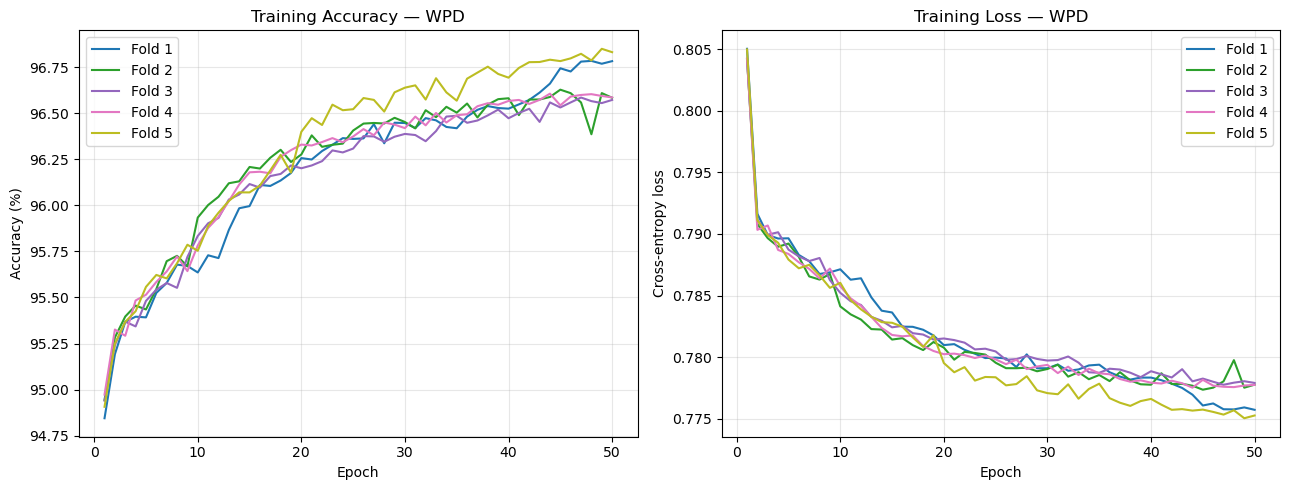

'/home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_fig6_wpd.png'

In [8]:
plot_training_curves(history_wpd, "wpd", is_primary=True)

## Run — STFT

In [9]:
y_true_stft, y_pred_stft, history_stft = train_cnn("stft")


  CNN  |  feature=STFT  |  file=STFT.npz
  X: (410000, 100)   y: (410000,)   classes: [0, 1, 2, 3]
  Dataset pre-loaded to GPU (156 MB)

--- Fold 1/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.7858  acc=95.78%
    Epoch  20/50  loss=0.7856  acc=95.80%
    Epoch  30/50  loss=0.7845  acc=95.91%
    Epoch  40/50  loss=0.7830  acc=96.06%
    Epoch  50/50  loss=0.7822  acc=96.14%
  Validation accuracy — fold 1: 93.39%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_stft_fold1.pt

--- Fold 2/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.7869  acc=95.67%
    Epoch  20/50  loss=0.7843  acc=95.93%
    Epoch  30/50  loss=0.7820  acc=96.16%
    Epoch  40/50  loss=0.7812  acc=96.25%
    Epoch  50/50  loss=0.7815  acc=96.21%
  Validation accuracy — fold 2: 75.00%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_stft_fold2.pt

--- Fold 3/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.7

In [10]:
metrics_stft = compute_metrics(y_true_stft, y_pred_stft, "stft")


Metrics — STFT
  Overall Accuracy (%)      86.8278
  Macro F1                  0.8632
  MCC                       0.8339
  Background Precision      0.9258
  Background Recall         0.9955
  Bebop Precision           0.9827
  Bebop Recall              0.8787
  AR Precision              0.9103
  AR Recall                 0.5997
  Phantom Precision         0.7284
  Phantom Recall            0.9992


Figure saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_supplementary_stft.png


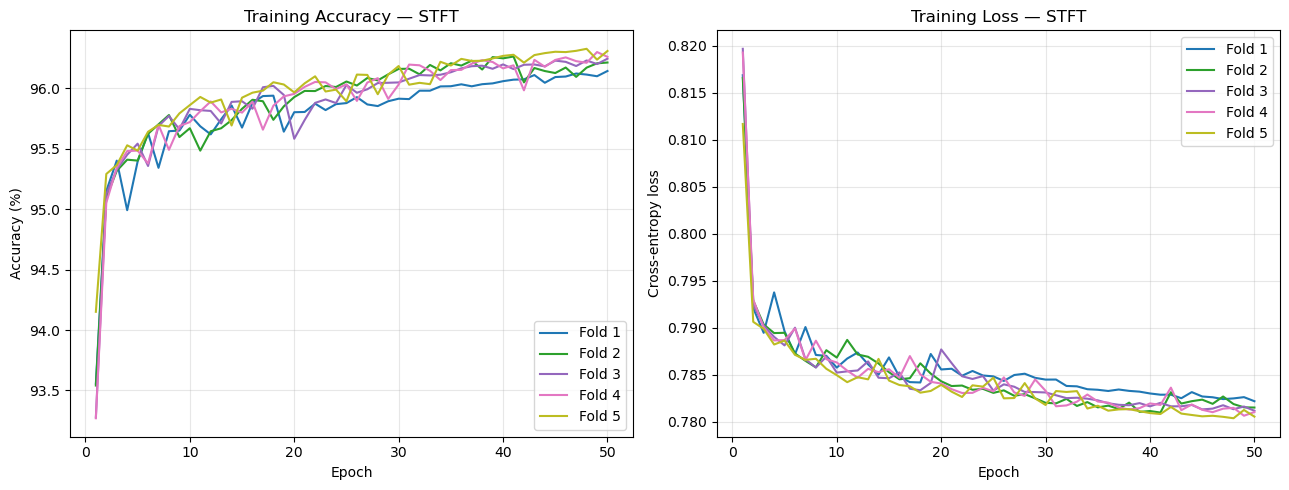

'/home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_supplementary_stft.png'

In [11]:
plot_training_curves(history_stft, "stft", is_primary=False)

## Run — PSD

In [12]:
y_true_psd, y_pred_psd, history_psd = train_cnn("psd")


  CNN  |  feature=PSD  |  file=PSD.npz
  X: (410000, 2048)   y: (410000,)   classes: [0, 1, 2, 3]

--- Fold 1/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.8901  acc=85.36%
    Epoch  20/50  loss=0.8894  acc=85.43%
    Epoch  30/50  loss=0.8881  acc=85.55%
    Epoch  40/50  loss=0.8353  acc=90.83%
    Epoch  50/50  loss=0.8205  acc=92.32%
  Validation accuracy — fold 1: 47.95%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_psd_fold1.pt

--- Fold 2/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.8898  acc=85.38%
    Epoch  20/50  loss=0.8896  acc=85.43%
    Epoch  30/50  loss=0.8428  acc=90.07%
    Epoch  40/50  loss=0.8892  acc=85.46%
    Epoch  50/50  loss=0.8438  acc=89.98%
  Validation accuracy — fold 2: 46.04%
  Checkpoint saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/checkpoints/v2/checkpoint_psd_fold2.pt

--- Fold 3/5  (train=328000, val=82000) ---
    Epoch  10/50  loss=0.8588  acc=88.48%
    Epoch  20/50  loss=0

In [13]:
metrics_psd = compute_metrics(y_true_psd, y_pred_psd, "psd")


Metrics — PSD
  Overall Accuracy (%)      54.7688
  Macro F1                  0.4817
  MCC                       0.5061
  Background Precision      0.0000
  Background Recall         0.0000
  Bebop Precision           0.9626
  Bebop Recall              0.8741
  AR Precision              0.9946
  AR Recall                 0.3167
  Phantom Precision         0.3605
  Phantom Recall            1.0000


Figure saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_supplementary_psd.png


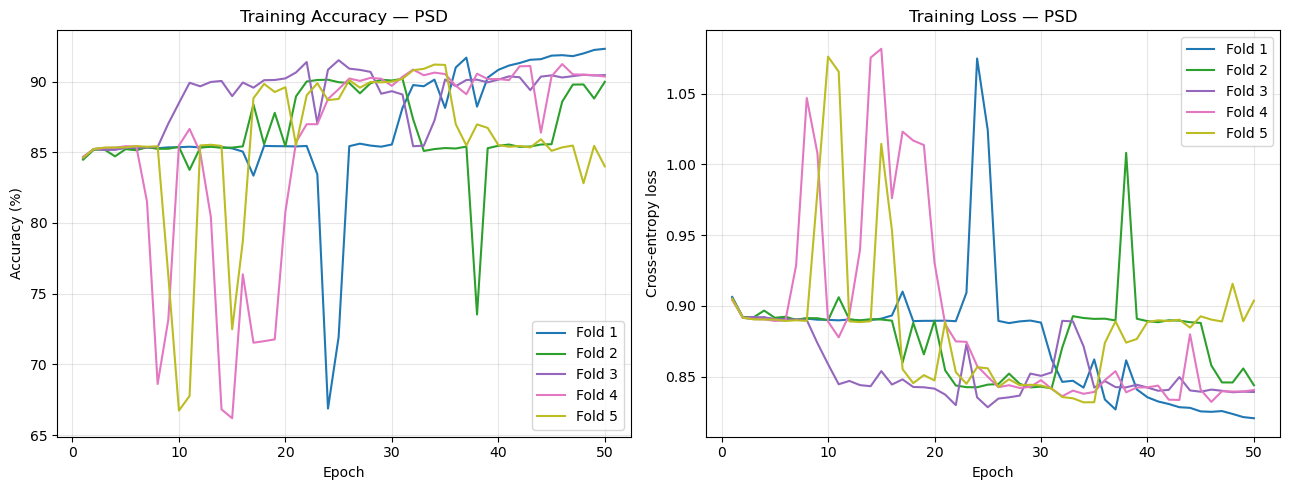

'/home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/figures/training_curves_supplementary_psd.png'

In [14]:
plot_training_curves(history_psd, "psd", is_primary=False)

## Save metrics CSV (Table 1)

In [15]:
METRIC_ROWS = [
    "Overall Accuracy (%)",
    "Macro F1",
    "MCC",
    "Background Precision",
    "Background Recall",
    "Bebop Precision",
    "Bebop Recall",
    "AR Precision",
    "AR Recall",
    "Phantom Precision",
    "Phantom Recall",
]

df_metrics = pd.DataFrame(
    {
        "Metric": METRIC_ROWS,
        "PSD":  [metrics_psd[r]  for r in METRIC_ROWS],
        "STFT": [metrics_stft[r] for r in METRIC_ROWS],
        "WPD":  [metrics_wpd[r]  for r in METRIC_ROWS],
    }
).set_index("Metric")

csv_path = os.path.join(results_path, "table1_metrics.csv")
df_metrics.to_csv(csv_path)
print(f"Metrics CSV saved: {csv_path}")
print()
print(df_metrics.round(4).to_string())

Metrics CSV saved: /home/ivan/work/ml/rfml-uav/data/drone-rf/results/v2/table1_metrics.csv

                          PSD     STFT      WPD
Metric                                         
Overall Accuracy (%)  54.7688  86.8278  91.5054
Macro F1               0.4817   0.8632   0.9168
MCC                    0.5061   0.8339   0.8919
Background Precision   0.0000   0.9258   0.9845
Background Recall      0.0000   0.9955   0.7967
Bebop Precision        0.9626   0.9827   0.9906
Bebop Recall           0.8741   0.8787   0.8809
AR Precision           0.9946   0.9103   0.7550
AR Recall              0.3167   0.5997   0.9826
Phantom Precision      0.3605   0.7284   1.0000
Phantom Recall         1.0000   0.9992   1.0000
